**Claudi Vall Müller - University of Barcelona**


Last modified: 08/11/2024


## Functions

In [1]:
from scipy.integrate import quad
import numpy as np
from math import sin, cos, tan, radians, asin, acos, atan, pi
from astropy.io import fits
import pandas as pd
import matplotlib.pyplot as plt

# Numerical Constants
c = 299792458/1000  # km/s
H_0 = 70  # km/s / Mpc
O_m = 0.3


### Angular diameter distance calculator
def integrand(z, H_0, O_m):
    '''Integrand for the angular diameter distance integral.'''
    Hz = H_0 * (O_m * (1+z)**3 + (1-O_m))**0.5
    f = 1/Hz    
    return f

def D_A(z_1, z_2):
    '''Computes angular diameter distance from two different redshift points, z_2 > z_1. For example,
    z_1 = 0 (observer), z_2 = z_S for computing D_S.
    c is the speed of light in km/s, H0 is the hubble constant in km/s/Mpc and O_m is omega matter from the
    cosmological model. Angular diameter distance returned is in Mpc.'''
    
    integral = quad(integrand, z_1, z_2, args = (H_0, O_m))
    D = c/(1 + z_2) * np.array(integral)
    
    return D

# Kappa star computation
def kappa_star_comput(sigma_star, z_L, z_S):
    '''Computes k* = sigma*/sigma_crit. Arguments are sigma* (in M_sun/pc^2), redshift of the lens (z_l) and 
    redshift of the source (z_s). Returns k*.'''
    c = 299792458  # m/s
    G = 6.67430e-11 # N m^2 kg^-2
    
    M_sun = 1.98847e30 # kg 
    pc = 30856775814913673 # m
    
    D_S = D_A(0, z_S)
    D_L = D_A(0, z_L)
    D_LS = D_A(z_L, z_S)
    
    sigma_crit = c**2/(4*pi*G) * pc/M_sun * D_S/(D_L * D_LS) * 1e-6    # M_sun/pc^2
    kappa_star = sigma_star/sigma_crit
    
    return kappa_star

## Dictionaries

In [2]:
# Lens and source redshifts
lens_redshift = {1: 0.544, 2: 0.397, 3: 0.397, 4: 0.397, 5: 0.566, 6: 0.443, 7: 0.308, 8: 0.591, 9: 0.591, 10: 0.870, 11: 0.375, 12: 0.397}
source_redshift = {1: 1.49, 2: 1.0054, 3: 1.0054, 4: 0.9397, 5: 6.2, 6: 2.37, 7: 2.6501, 8: 4.8, 9: 4.8, 10: 2.1878, 11: 1.2567, 12: 2.091}


# Distance from images to MaCL from observations
theta_dict = {1: +0.13, 2: 'nan', 3: 'nan', 4: +0.06, 5: -0.009, 6: +0.55, 7: -0.15, 8: -0.1, 9: -0.32, 10: +7.5e-3, 11: -0.6, 12: -0.05}


# k_star from intracluster light stars. Data obtained from the original papers
k_star_dict = {1: kappa_star_comput(19, lens_redshift[1], source_redshift[1])[0], 
               2: kappa_star_comput(7.943, lens_redshift[2], source_redshift[2])[0], 
               3: kappa_star_comput(7.943, lens_redshift[3], source_redshift[3])[0], 
               4: 0.02, 
               5: kappa_star_comput(10, lens_redshift[5], source_redshift[5])[0], 
               6: 'nan', 
               7: kappa_star_comput(11.55, lens_redshift[7], source_redshift[7])[0], 
               8: 'nan', 
               9: 'nan', 
               10: 'nan',
               11: kappa_star_comput(4.37, lens_redshift[11], source_redshift[11])[0], 
               12: 'nan'}

# $r_w$ computation

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Microcaustic corrugated band widths dictionary
r_w_dict = {1: 'nan', 2: 'nan', 3: 'nan', 4: 'nan', 5: 'nan', 6: 'nan', 7: 'nan', 8: 'nan', 9: 'nan', 10: 'nan' , 11: 'nan', 12: 'nan'}
# Reference value for corrugated band widths dictionary with k* = 0.01 k0
r_w_ref_dict = {1: 'nan', 2: 'nan', 3: 'nan', 4: 'nan', 5: 'nan', 6: 'nan', 7: 'nan', 8: 'nan', 9: 'nan', 10: 'nan' , 11: 'nan', 12: 'nan'}


parameters_dataframe = pd.read_csv('Numerical results/Magnification parameters table.dat', sep = '\t')
event_number_list = list(parameters_dataframe['i'])


# d^(-1) (band width per k* unit) dictionary
d_inv_dict = {1: 'nan', 2: 'nan', 3: 'nan', 4: 'nan', 5: 'nan', 6: 'nan', 7: 'nan', 8: 'nan', 9: 'nan', 10: 'nan' , 11: 'nan', 12: 'nan'}
for event_number in event_number_list:
        idx = event_number_list.index(event_number)
        d_i = parameters_dataframe['    d (arcmin^-1)    '][idx]
        d_inv_i = 1/d_i * 60  # arcsec
        d_inv_dict[int(event_number)] = d_inv_i


# k_0 dictionary
k_0_dict = {1: 'nan', 2: 'nan', 3: 'nan', 4: 'nan', 5: 'nan', 6: 'nan', 7: 'nan', 8: 'nan', 9: 'nan', 10: 'nan' , 11: 'nan', 12: 'nan'}
for event_number in event_number_list:
        idx = event_number_list.index(event_number)
        k_0_i = parameters_dataframe['    κ_0    '][idx]
        k_0_dict[int(event_number)] = k_0_i


        
# mean d_inv    
d_inv_values = np.array([])
for idx in d_inv_dict:
    if d_inv_dict[idx] != 'nan':
        d_inv_values = np.append(d_inv_values, d_inv_dict[idx])    
mean_d_inv = np.mean(d_inv_values)

# mean k_0    
k_0_values = np.array([])
for idx in k_0_dict:
    if k_0_dict[idx] != 'nan':
        k_0_values = np.append(k_0_values, k_0_dict[idx])    
mean_k_0 = np.mean(k_0_values)


# r_w and r_w_ref computation 
for idx in d_inv_dict:
    d_inv = d_inv_dict[idx]
    k_star = k_star_dict[idx]
    k_0 = k_0_dict[idx]
    # use mean values for case LS6, where we don't have g nor k0
    if k_0 == 'nan':
        k_0 = mean_k_0
    if d_inv == 'nan':
        d_inv = mean_d_inv
    
    r_w_ref_dict[idx] = d_inv * k_0 * 0.01
    if k_star != 'nan':
        r_w_dict[idx] = d_inv * k_star
        

print('Dictionaries successfully created.')
print('\n\nθ dictionary:\n', theta_dict)
print('\nκ* dictionary:\n', k_star_dict)
print('\nr_w (using κ* from κ* dict) dictionary (arcsec):\n', r_w_dict)
print('\nr_w (using κ* = 0.01 κ0) dictionary (arcsec):\n', r_w_ref_dict)


Dictionaries successfully created.


θ dictionary:
 {1: 0.13, 2: 'nan', 3: 'nan', 4: 0.06, 5: -0.009, 6: 0.55, 7: -0.15, 8: -0.1, 9: -0.32, 10: 0.0075, 11: -0.6, 12: -0.05}

κ* dictionary:
 {1: 0.008004929881289332, 2: 0.0028211700217982286, 3: 0.0028211700217982286, 4: 0.02, 5: 0.006032027813850829, 6: 'nan', 7: 0.005172265291431559, 8: 'nan', 9: 'nan', 10: 'nan', 11: 0.0017436353909516008, 12: 'nan'}

r_w (using κ* from κ* dict) dictionary (arcsec):
 {1: 0.09970973866392681, 2: 0.02904263414865595, 3: 0.02904263414880703, 4: 0.1748081324237239, 5: 0.14481909064752885, 6: 'nan', 7: 0.08110608764464759, 8: 'nan', 9: 'nan', 10: 'nan', 11: 0.03294427355581496, 12: 'nan'}

r_w (using κ* = 0.01 κ0) dictionary (arcsec):
 {1: 0.10365507299983091, 2: 0.07635812299740193, 3: 0.06476502404785181, 4: 0.059948986139386935, 5: 0.14174850941509912, 6: 0.12550242231361666, 7: 0.11381411136877324, 8: 0.1592465558460072, 9: 0.16777591845941497, 10: 0.15771610559590415, 11: 0.13285569055016339, 12: 0.1

In [13]:
# ####   IN CASE WE WANT TO USE LS6 EVENT   ####
# suma = 0
# for i in range(1, 6):
#     suma += d_inv_dict[i]
    
# for j in range(7, 13):
#     suma += d_inv_dict[j]
    
# mean = suma/11
# d_inv_dict[6] = 18.16828497374016

## Figure 1. Separations plot

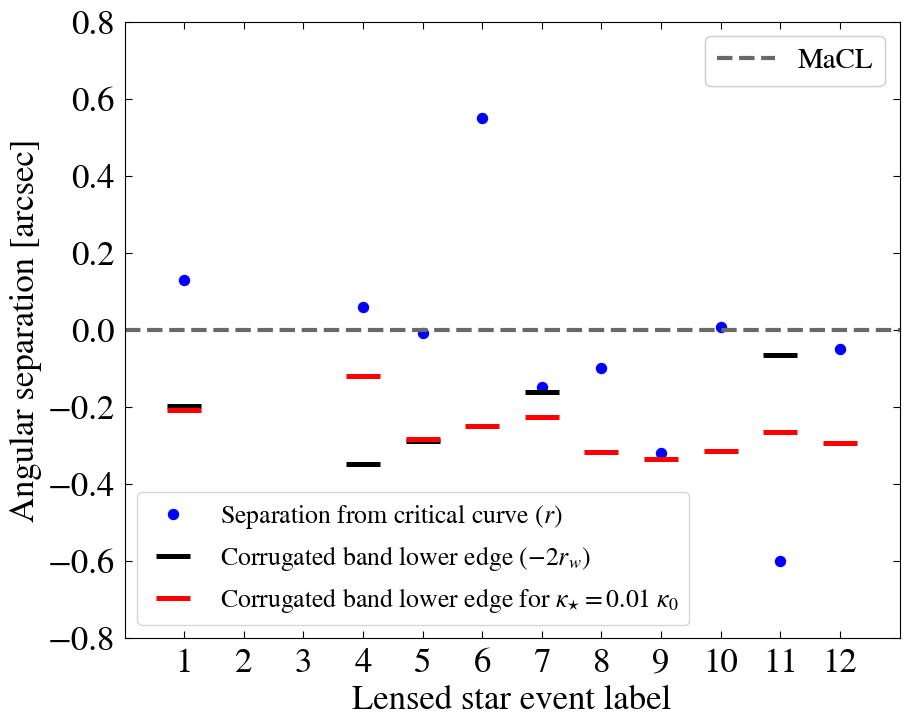

In [5]:
import matplotlib.pyplot as plt 
import numpy as np


theta_values = np.array([])
r_w_values = np.array([])
r_w_ref_values = np.array([])
idx_values = np.array([])


for i, j, k in zip(theta_dict, r_w_dict, r_w_ref_dict):
    idx_values = np.append(idx_values, i)
    if str(theta_dict[i]) != 'nan':     # cases without theta info are left blank in all values    
        theta_values = np.append(theta_values, theta_dict[i])
        if str(r_w_ref_dict[k]) != 'nan':
            r_w_ref_values = np.append(r_w_ref_values, r_w_ref_dict[k])
        else:
            r_w_ref_values = np.append(r_w_ref_values, -1000)
        if str(r_w_dict[j]) != 'nan':
            r_w_values = np.append(r_w_values, r_w_dict[j])
        else:
            r_w_values = np.append(r_w_values, -1000)
    else:
        theta_values = np.append(theta_values, -1000)   # value that will not appear in the plot
        r_w_ref_values = np.append(r_w_ref_values, -1000)   # value that will not appear in the plot
        r_w_values = np.append(r_w_values, -1000)
        

fontsize_value = 25
plt.rcParams.update({'font.size': fontsize_value})
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

fig, ax = plt.subplots(1,1, figsize = (10,8))

ax.set_xlabel('Lensed star event label')
ax.set_ylabel('Angular separation [arcsec]')
ax.set_xticks(np.arange(1, 13, 1))
ax.set_yticks(np.arange(-0.8, 0.9, 0.2))
ax.set_ylim(bottom = -0.8, top = 0.8)
ax.set_xlim([0, 13])

width_parameter = 1.2
dot_size = 12 * width_parameter
line_width = 3 * width_parameter

# Separation
ax.plot(idx_values, theta_values, 'b.', markersize = dot_size, label = 'Separation from critical curve ($r$)')

# Corrugated band width
upper_edge = r_w_values - r_w_values
upper_edge[1] = -100     # don't show cases 2 and 3
upper_edge[2] = -100
lower_edge = -r_w_values - r_w_values
# ax.plot(idx_values, upper_edge, 'k_', markersize = 25, markeredgewidth = line_width, label = '')
ax.plot(idx_values, lower_edge, 'k_', markersize = 25, markeredgewidth = line_width, label = 'Corrugated band lower edge ($-2r_w$)')

# Corrugated band width using kstar = 1% of k0
upper_edge_ref = r_w_ref_values - r_w_ref_values
upper_edge_ref[1] = -100 # don't show cases 2 and 3
upper_edge_ref[2] = -100
lower_edge_ref = -r_w_ref_values - r_w_ref_values

# ax.plot(idx_values, upper_edge_ref, 'r_', markersize = 18, markeredgewidth = line_width, label = '')
ax.plot(idx_values, lower_edge_ref, 'r_', markersize = 25, markeredgewidth = line_width, label = 'Corrugated band lower edge for $\kappa_{\star} = 0.01 \ \kappa_0$')


ax.tick_params(direction = 'in', top = True, right = True, length = 5)
ax.tick_params(axis='both', which='major', pad=7)
MaCL = ax.plot([i for i in range(0, 15)], [0 for i in range(0, 15)], linestyle = 'dashed', linewidth = 3, color = 'dimgray')

legend_1 = plt.legend(fontsize = fontsize_value/1.35, loc = 'lower left')
legend_2 = plt.legend(MaCL, ["MaCL"], fontsize = fontsize_value/1.2, loc = 'upper right')
ax.add_artist(legend_1)
ax.add_artist(legend_2)
plt.savefig('Figures/Figure 1 Critical curve separations plot.png', bbox_inches = 'tight', dpi = 400)

plt.show()